# 📊 TCC — Análise de Sentimento no Mercado Financeiro Brasileiro
## FASES 3 — Estudo de simulação controlada (v3)



| Item | v2 (anterior) | v3 (este notebook) |
|---|---|---|
| IS(d) sintético | gerado silenciosamente com peso fixo 0,45 | gerado por função explícita `gerar_IS_simulado(alpha)`, com **alpha declarado** |
| Correlação por defasagem | bug: lag +k e −k calculavam a mesma coisa | função `correlacoes_por_lag` com convenção única: **k > 0 ⇒ IS(d) vs R(d+k)** |
| Regressão | só simultânea (IS(d) vs R(d)) | simultânea **e defasada** (R(d+1) ~ IS(d) + controles) |
| Fase 4 — features | modelo "sem sentimento" não tinha R(d); Trends contava como sentimento | R(d) entra nos dois cenários; Trends vai para o cenário base |
| Novo | — | **Análise de sensibilidade**: repete tudo para alpha ∈ {0; 0,15; 0,30; 0,45}. Com alpha = 0 (sem sinal) o pipeline **deve** encontrar nada — é o teste de que a instrumentação não inventa resultado |
| Novo | — | Cenário "IS real": correlação com as 15 manchetes reais (n = 15), reportada como está |

⚠️ Execute **após** as Fases 1 e 2 (precisa de `dados_mercado_2020_2024.csv`, `IS_diario.csv`, `google_trends_diario.csv`).

**Por que simular?** O corpus real de manchetes datadas tem 15 observações — insuficiente para qualquer teste estatístico diário. A simulação responde a outra pergunta, legítima e verificável: *se existisse um índice de sentimento com um dado grau de antecipação do mercado, o pipeline proposto (correlações, regressão, análise de eventos e classificadores) seria capaz de detectá-lo e aproveitá-lo?*

In [ ]:
# — Monta Google Drive e configura pasta do TCC (idêntico às fases anteriores) —
from google.colab import drive
drive.mount('/content/drive')

import os, shutil
PASTA_DRIVE = '/content/drive/MyDrive/TCC_dados'
os.makedirs(PASTA_DRIVE, exist_ok=True)
if os.path.islink('dados_tcc'):
    os.unlink('dados_tcc')
if os.path.exists('dados_tcc') and not os.path.islink('dados_tcc'):
    shutil.rmtree('dados_tcc')
os.symlink(PASTA_DRIVE, 'dados_tcc')
print('✅ Drive montado:', PASTA_DRIVE)

arquivos = ['dados_tcc/dados_mercado_2020_2024.csv', 'dados_tcc/IS_diario.csv', 'dados_tcc/google_trends_diario.csv']
for a in arquivos:
    print(('✅' if os.path.exists(a) else '❌'), a)


Mounted at /content/drive
✅ Drive montado: /content/drive/MyDrive/TCC_dados
✅ dados_tcc/dados_mercado_2020_2024.csv
✅ dados_tcc/IS_diario.csv
✅ dados_tcc/google_trends_diario.csv


In [ ]:
!pip install -q pandas numpy matplotlib seaborn scipy statsmodels scikit-learn
import pandas as pd, numpy as np, warnings
import matplotlib.pyplot as plt, matplotlib.dates as mdates, seaborn as sns
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.figsize': (13,5), 'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 11})
print('✅ Importações concluídas')


✅ Importações concluídas


## 📁 BLOCO 1 — Carrega dados das Fases 1 e 2

In [ ]:
df_mercado = pd.read_csv('dados_tcc/dados_mercado_2020_2024.csv', index_col=0, parse_dates=True)
df_mercado = df_mercado.dropna(subset=['retorno_ibov'])
print(f'✅ Mercado: {len(df_mercado):,} pregões ({df_mercado.index.min().date()} a {df_mercado.index.max().date()})')

df_IS_real = pd.read_csv('dados_tcc/IS_diario.csv', parse_dates=['data']).set_index('data')
print(f'✅ IS(d) REAL (manchetes classificadas na Fase 2): {len(df_IS_real)} observações')

df_trends = pd.read_csv('dados_tcc/google_trends_diario.csv', index_col=0, parse_dates=True)
col_ibov = next((c for c in df_trends.columns if 'ibov' in c.lower()), df_trends.columns[0])
df_mercado['trends_ibovespa'] = df_trends[col_ibov].reindex(df_mercado.index).ffill().bfill()
print(f'✅ Google Trends: coluna "{col_ibov}" alinhada ao calendário de pregões')

retornos = df_mercado['retorno_ibov'].copy()


✅ Mercado: 1,243 pregões (2020-01-03 a 2024-12-30)
✅ IS(d) REAL (manchetes classificadas na Fase 2): 15 observações
✅ Google Trends: coluna "Ibovespa" alinhada ao calendário de pregões


## 🧪 BLOCO 2 — Gerador do IS(d) simulado

$$IS_{sim}(d) = \alpha \cdot z\big(R(d+1)\big) + (1-\alpha)\cdot \varepsilon_d, \qquad \varepsilon_d \sim N(0,\,0{,}4^2)$$

normalizado para o intervalo [−1, +1]. O parâmetro **alpha** é a "força do sinal antecipatório" plantado: com alpha = 0 o índice é puro ruído; com alpha = 0,45 reproduz-se exatamente a série usada na v2 (mesma semente, mesma ordem de geração).

> Isso é o que estava escondido na v2. Agora é uma **hipótese declarada** do estudo.

In [ ]:
def gerar_IS_simulado(retornos, alpha, seed=42, sigma=0.4):
    """IS(d) simulado com sinal antecipatório de força alpha (0 = só ruído)."""
    np.random.seed(seed)
    sinal = retornos.shift(-1).fillna(0)
    sinal_norm = (sinal - sinal.mean()) / sinal.std()
    ruido = np.random.normal(0, sigma, len(retornos))
    IS = alpha * sinal_norm.values + (1 - alpha) * ruido
    if np.abs(IS).max() > 0:
        IS = IS / np.abs(IS).max()
    return pd.Series(IS, index=retornos.index, name='IS')

ALPHAS = [0.00, 0.15, 0.30, 0.45]
ALPHA_PRINCIPAL = 0.45   # cenário detalhado (reproduz a v2)

# Teste rápido: reproduz o r = 0,9005 da v2?
IS_teste = gerar_IS_simulado(retornos, 0.45)
r_teste = pearsonr(IS_teste.values[:-1], retornos.values[1:])[0]
print(f'alpha=0.45 → r[IS(d), R(d+1)] = {r_teste:.4f}  (v2 reportava 0.9005)')


alpha=0.45 → r[IS(d), R(d+1)] = 0.9005  (v2 reportava 0.9005)


## 📐 BLOCO 3 — Funções de análise (correlação, regressão, eventos)

Convenção única de defasagem (corrige o bug da v2):

- **k > 0**: IS(d) × R(d+k) → "o sentimento de hoje antecipa o retorno de k dias à frente"
- **k = 0**: IS(d) × R(d) → simultâneo
- **k < 0**: IS(d) × R(d+k) = IS(d) × R(d−|k|) → "o sentimento reage ao retorno passado"


In [ ]:
def correlacoes_por_lag(IS, ret, lags=(-1, 0, 1, 2, 3)):
    linhas = []
    for k in lags:
        if k > 0:   x, y = IS.values[:-k], ret.values[k:]
        elif k == 0: x, y = IS.values, ret.values
        else:       x, y = IS.values[-k:], ret.values[:k]
        assert len(x) == len(y)
        rp, pp = pearsonr(x, y); rs, ps = spearmanr(x, y)
        desc = ('IS(d) × R(d) [simultâneo]' if k == 0 else
                f'IS(d) → R(d+{k}) [antecipa {k} dia(s)]' if k > 0 else
                f'IS(d) ← R(d{k}) [reage ao passado]')
        linhas.append({'Lag': k, 'Descrição': desc, 'Pearson r': rp, 'p (Pearson)': pp,
                       'Spearman ρ': rs, 'p (Spearman)': ps, 'n': len(x)})
    return pd.DataFrame(linhas)

def regressoes(df, IS):
    """Retorna (modelo simultâneo, modelo defasado). Controles medidos em d."""
    d = df.copy()
    d['IS'] = IS
    d['delta_cambio'] = d['cambio_brlusd'].pct_change() * 100
    d['selic_proxy'] = d['selic'] if 'selic' in d.columns else 0.0
    d['R_futuro'] = d['retorno_ibov'].shift(-1)
    X_vars = ['IS', 'delta_cambio', 'selic_proxy'] + (['vix'] if 'vix' in d.columns else [])
    d = d.dropna(subset=X_vars + ['retorno_ibov', 'R_futuro'])
    X = sm.add_constant(d[X_vars])
    m0 = sm.OLS(d['retorno_ibov'], X).fit(cov_type='HC3')   # R(d)   ~ IS(d) + controles
    m1 = sm.OLS(d['R_futuro'],     X).fit(cov_type='HC3')   # R(d+1) ~ IS(d) + controles
    return m0, m1

EVENTOS = [
    {'data': '2020-03-23', 'tipo': 'Crise',       'desc': 'Mínima COVID-19'},
    {'data': '2020-06-17', 'tipo': 'Copom',       'desc': 'Selic 2,25% (mínima histórica)'},
    {'data': '2021-03-17', 'tipo': 'Copom',       'desc': 'Início do ciclo de alta'},
    {'data': '2022-02-24', 'tipo': 'Crise',       'desc': 'Invasão da Ucrânia'},
    {'data': '2022-08-03', 'tipo': 'Copom',       'desc': 'Selic em 13,75%'},
    {'data': '2022-10-30', 'tipo': 'Político',    'desc': 'Resultado eleições 2022'},
    {'data': '2023-01-12', 'tipo': 'Corporativo', 'desc': 'Crise Americanas'},
    {'data': '2023-08-02', 'tipo': 'Copom',       'desc': 'Início ciclo de corte'},
    {'data': '2024-09-18', 'tipo': 'Global',      'desc': 'Corte de juros do Fed'},
]

def analise_eventos(df, IS, janela=5):
    d = df.copy(); d['IS'] = IS
    out = []
    for ev in EVENTOS:
        t = pd.Timestamp(ev['data'])
        if not (d.index.min() <= t <= d.index.max()):
            continue
        pre = d[(d.index < t)].tail(janela)
        pos = d[(d.index > t)].head(janela)
        out.append({'Data': ev['data'], 'Tipo': ev['tipo'], 'Evento': ev['desc'],
                    'IS_pré': pre['IS'].mean(), 'IS_pós': pos['IS'].mean(),
                    'ΔIS': pos['IS'].mean() - pre['IS'].mean(),
                    'Ret_pré (%)': pre['retorno_ibov'].mean(), 'Ret_pós (%)': pos['retorno_ibov'].mean()})
    df_ev = pd.DataFrame(out)
    # "Concordância": ΔIS e retorno pós-evento têm o mesmo sinal?
    df_ev['Concorda'] = np.sign(df_ev['ΔIS']) == np.sign(df_ev['Ret_pós (%)'])
    return df_ev

print('✅ Funções definidas')


✅ Funções definidas


## 🤖 BLOCO 4 — Fase 4: função de comparação SEM × COM sentimento

Alterações em relação à v2, e o porquê:

- `retorno_lag0` (= R(d), o retorno **do próprio dia**) entra nos dois cenários. Na v2 o cenário base não tinha R(d), enquanto o cenário com sentimento tinha `IS_lag1`, que carrega informação de R(d). A comparação era desigual.
- `trends_lag1` sai do bloco "sentimento" e entra no bloco base: Google Trends é atenção, não sentimento classificado.
- Features de sentimento: `IS_atual` = IS(d), `IS_lag1`, `IS_ma7` (média dos últimos 7 dias, incluindo d), `IS_extremo` (|IS| > 0,5). Todas conhecidas no fechamento do dia d — no desenho da simulação o IS(d) é, por definição, o índice publicado no dia d.
- Target: 1 se R(d+1) > 0.

In [ ]:
FEATURES_BASE = ['retorno_lag0', 'retorno_lag1', 'retorno_lag2', 'retorno_ma5',
                 'volatilidade_5d', 'volatilidade_20d', 'delta_cambio', 'vix_lag1', 'trends_lag1']
FEATURES_SENT = ['IS_atual', 'IS_lag1', 'IS_ma7', 'IS_extremo']

MODELOS = {
    'Regressão Logística': LogisticRegression(max_iter=1000, C=0.5, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42),
}

def montar_features(df, IS):
    f = df.copy(); f['IS'] = IS
    f['retorno_lag0']     = f['retorno_ibov']
    f['retorno_lag1']     = f['retorno_ibov'].shift(1)
    f['retorno_lag2']     = f['retorno_ibov'].shift(2)
    f['retorno_ma5']      = f['retorno_ibov'].rolling(5).mean()
    f['volatilidade_5d']  = f['retorno_ibov'].rolling(5).std()
    f['volatilidade_20d'] = f['retorno_ibov'].rolling(20).std()
    f['delta_cambio']     = f['cambio_brlusd'].pct_change() * 100
    f['vix_lag1']         = f['vix'].shift(1) if 'vix' in f.columns else 0.0
    f['trends_lag1']      = f['trends_ibovespa'].shift(1)
    f['IS_atual']         = f['IS']
    f['IS_lag1']          = f['IS'].shift(1)
    f['IS_ma7']           = f['IS'].rolling(7).mean()
    f['IS_extremo']       = (f['IS'].abs() > 0.5).astype(int)
    f['target']           = (f['retorno_ibov'].shift(-1) > 0).astype(int)
    f = f.dropna(subset=FEATURES_BASE + FEATURES_SENT + ['target'])
    # última linha: shift(-1) do target é NaN "disfarçado" de 0 → remove
    return f.iloc[:-1]

def comparar_sem_com(df_feat, verbose=False):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    y = df_feat['target']
    res = []
    for nome, clf in MODELOS.items():
        for cenario, feats in [('Sem sentimento', FEATURES_BASE), ('Com sentimento', FEATURES_BASE + FEATURES_SENT)]:
            pipe = Pipeline([('scaler', StandardScaler()), ('clf', clf)])
            X = df_feat[feats]
            f1  = cross_val_score(pipe, X, y, cv=skf, scoring='f1',        n_jobs=-1)
            acc = cross_val_score(pipe, X, y, cv=skf, scoring='accuracy',  n_jobs=-1)
            prc = cross_val_score(pipe, X, y, cv=skf, scoring='precision', n_jobs=-1)
            res.append({'Modelo': nome, 'Cenário': cenario, 'F1': f1.mean(), 'F1_std': f1.std(),
                        'Acurácia': acc.mean(), 'Precisão': prc.mean(), 'n_features': len(feats)})
            if verbose: print(f'  [{cenario}] {nome}: F1={f1.mean():.4f} ± {f1.std():.4f}')
    return pd.DataFrame(res)

print('✅ Funções da Fase 4 definidas')


✅ Funções da Fase 4 definidas


## 🔬 BLOCO 5 — Análise de sensibilidade (alpha ∈ {0; 0,15; 0,30; 0,45})

Esta é a **contribuição metodológica** da versão v3. Para cada alpha, o pipeline inteiro é executado e registram-se: correlação IS(d)→R(d+1), R² da regressão defasada, concordância nos eventos e o ganho de F1 ao incluir sentimento. Leitura esperada:

- **alpha = 0** → correlação ≈ 0, R² ≈ 0, ganho de F1 ≈ 0. Se isso não acontecer, há vazamento no pipeline.
- **alpha crescente** → métricas crescem monotonicamente. Isso mostra que a instrumentação **detecta sinal quando ele existe**.

(Leva alguns minutos: 4 cenários × 3 modelos × 2 cenários × 3 métricas × 5 folds.)

In [ ]:
sens = []
resultados_por_alpha = {}
for a in ALPHAS:
    IS_a = gerar_IS_simulado(retornos, a)
    corr = correlacoes_por_lag(IS_a, retornos)
    m0, m1 = regressoes(df_mercado, IS_a)
    ev = analise_eventos(df_mercado, IS_a)
    feat = montar_features(df_mercado, IS_a)
    comp = comparar_sem_com(feat)
    ganho = (comp[comp['Cenário']=='Com sentimento']['F1'].mean()
             - comp[comp['Cenário']=='Sem sentimento']['F1'].mean())
    r1 = corr.loc[corr['Lag']==1].iloc[0]
    sens.append({'alpha': a,
                 'r IS(d)→R(d+1)': r1['Pearson r'], 'p': r1['p (Pearson)'],
                 'ρ Spearman': r1['Spearman ρ'],
                 'R² aj. simultâneo': m0.rsquared_adj, 'R² aj. defasado': m1.rsquared_adj,
                 'p(IS) defasado': m1.pvalues['IS'],
                 'Eventos concordantes': f"{int(ev['Concorda'].sum())}/{len(ev)}",
                 'F1 sem (média)': comp[comp['Cenário']=='Sem sentimento']['F1'].mean(),
                 'F1 com (média)': comp[comp['Cenário']=='Com sentimento']['F1'].mean(),
                 'ΔF1 médio': ganho})
    resultados_por_alpha[a] = {'IS': IS_a, 'corr': corr, 'm0': m0, 'm1': m1, 'ev': ev, 'feat': feat, 'comp': comp}
    print(f'✅ alpha={a:.2f} concluído | r(+1)={r1["Pearson r"]:+.4f} | R²def={m1.rsquared_adj:.4f} | ΔF1={ganho:+.4f}')

df_sens = pd.DataFrame(sens)
print('\n' + '=' * 100)
print(' TABELA DE SENSIBILIDADE — força do sinal plantado × capacidade de detecção do pipeline')
print('=' * 100)
print(df_sens.round(4).to_string(index=False))
df_sens.to_csv('dados_tcc/sensibilidade_alpha_v3.csv', index=False)


✅ alpha=0.00 concluído | r(+1)=+0.0023 | R²def=-0.0021 | ΔF1=+0.0059
✅ alpha=0.15 concluído | r(+1)=+0.4092 | R²def=0.1666 | ΔF1=+0.0677
✅ alpha=0.30 concluído | r(+1)=+0.7356 | R²def=0.5413 | ΔF1=+0.1923
✅ alpha=0.45 concluído | r(+1)=+0.9005 | R²def=0.8111 | ΔF1=+0.2982

 TABELA DE SENSIBILIDADE — força do sinal plantado × capacidade de detecção do pipeline
 alpha  r IS(d)→R(d+1)      p  ρ Spearman  R² aj. simultâneo  R² aj. defasado  p(IS) defasado Eventos concordantes  F1 sem (média)  F1 com (média)  ΔF1 médio
  0.00          0.0023 0.9358     -0.0337             0.0142          -0.0021          0.9086                  3/9          0.5216          0.5275     0.0059
  0.15          0.4092 0.0000      0.2959             0.0167           0.1666          0.0000                  4/9          0.5216          0.5893     0.0677
  0.30          0.7356 0.0000      0.6083             0.0267           0.5413          0.0000                  4/9          0.5216          0.7139     0.1923
  0.45

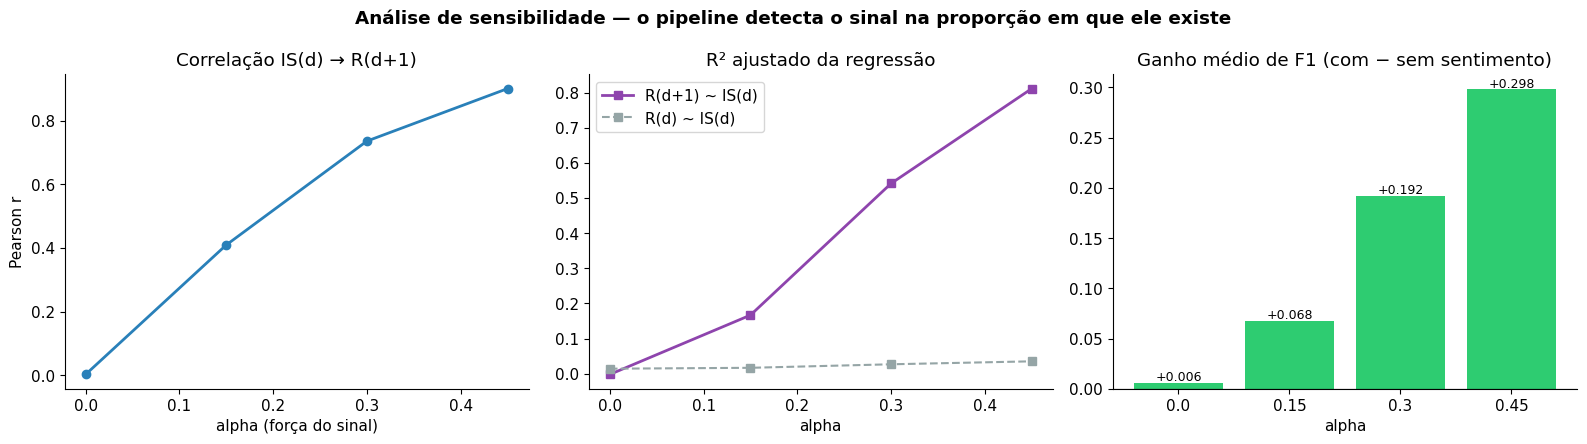

✅ Figura salva: dados_tcc/fig14_sensibilidade_alpha.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(df_sens['alpha'], df_sens['r IS(d)→R(d+1)'], 'o-', color='#2980b9', lw=2)
axes[0].set_title('Correlação IS(d) → R(d+1)'); axes[0].set_xlabel('alpha (força do sinal)'); axes[0].set_ylabel('Pearson r')
axes[1].plot(df_sens['alpha'], df_sens['R² aj. defasado'], 's-', color='#8e44ad', lw=2, label='R(d+1) ~ IS(d)')
axes[1].plot(df_sens['alpha'], df_sens['R² aj. simultâneo'], 's--', color='#95a5a6', lw=1.5, label='R(d) ~ IS(d)')
axes[1].set_title('R² ajustado da regressão'); axes[1].set_xlabel('alpha'); axes[1].legend()
axes[2].bar(df_sens['alpha'].astype(str), df_sens['ΔF1 médio'], color=['#e74c3c' if g <= 0 else '#2ecc71' for g in df_sens['ΔF1 médio']])
axes[2].axhline(0, color='black', lw=0.8); axes[2].set_title('Ganho médio de F1 (com − sem sentimento)'); axes[2].set_xlabel('alpha')
for i, g in enumerate(df_sens['ΔF1 médio']):
    axes[2].text(i, g + (0.002 if g >= 0 else -0.006), f'{g:+.3f}', ha='center', fontsize=9)
plt.suptitle('Análise de sensibilidade — o pipeline detecta o sinal na proporção em que ele existe', fontweight='bold')
plt.tight_layout()
plt.savefig('dados_tcc/fig14_sensibilidade_alpha.png', dpi=150, bbox_inches='tight'); plt.show()
print('✅ Figura salva: dados_tcc/fig14_sensibilidade_alpha.png')


## 📊 BLOCO 6 — Cenário principal (alpha = 0,45): tabelas detalhadas

Mesmo cenário da v2, agora com a defasagem correta e a regressão defasada.

In [ ]:
R = resultados_por_alpha[ALPHA_PRINCIPAL]
df_mercado['IS'] = R['IS']; df_mercado['IS_ma7'] = df_mercado['IS'].rolling(7, min_periods=1).mean()

print('=' * 95)
print(f' TABELA — Correlação IS(d) × retorno Ibovespa por defasagem (alpha = {ALPHA_PRINCIPAL})')
print('=' * 95)
print(R['corr'].round(4).to_string(index=False))
R['corr'].to_csv('dados_tcc/correlacoes_IS_ibovespa_v3.csv', index=False)

# Cenário "IS real": 15 manchetes — correlação com R(d+1) nas datas disponíveis (ilustrativo, n=15)
ret_next = retornos.shift(-1)
datas_ok = [d for d in df_IS_real.index if d in ret_next.index]
x_real = df_IS_real.loc[datas_ok, 'IS'].values; y_real = ret_next.loc[datas_ok].values
rr, pr = pearsonr(x_real, y_real); rs_, ps_ = spearmanr(x_real, y_real)
print(f'\nCENÁRIO REAL (15 manchetes da Fase 2): n={len(x_real)} | Pearson r={rr:+.4f} (p={pr:.3f}) | Spearman ρ={rs_:+.4f} (p={ps_:.3f})')
print('   → reportar no TCC como está: amostra insuficiente para inferência.')


 TABELA — Correlação IS(d) × retorno Ibovespa por defasagem (alpha = 0.45)
 Lag                          Descrição  Pearson r  p (Pearson)  Spearman ρ  p (Spearman)    n
  -1  IS(d) ← R(d-1) [reage ao passado]     0.0659       0.0203     -0.0124        0.6627 1242
   0          IS(d) × R(d) [simultâneo]    -0.1453       0.0000     -0.0573        0.0434 1243
   1 IS(d) → R(d+1) [antecipa 1 dia(s)]     0.9005       0.0000      0.8253        0.0000 1242
   2 IS(d) → R(d+2) [antecipa 2 dia(s)]    -0.1486       0.0000     -0.0675        0.0173 1241
   3 IS(d) → R(d+3) [antecipa 3 dia(s)]     0.0771       0.0066     -0.0069        0.8073 1240

CENÁRIO REAL (15 manchetes da Fase 2): n=13 | Pearson r=-0.0963 (p=0.754) | Spearman ρ=+0.1464 (p=0.633)
   → reportar no TCC como está: amostra insuficiente para inferência.


 REGRESSÃO SIMULTÂNEA — R(d) ~ IS(d) + ΔCâmbio + Selic + VIX
  R² ajustado: 0.0352 | F = 1.962 (p = 0.0981) | n = 1241 | DW = 2.029
  Variável            Coef   EP(HC3)        p  Sig
  const             0.7375    0.4430   0.0960    *
  IS               -1.9876    1.3422   0.1386     
  delta_cambio      0.0515    0.0520   0.3221     
  selic_proxy      -4.5243    2.7312   0.0976    *
  vix              -0.0267    0.0198   0.1759     
  Jarque-Bera p = 0.0000 | cond. number = 1454

 REGRESSÃO DEFASADA   — R(d+1) ~ IS(d) + ΔCâmbio + Selic + VIX
  R² ajustado: 0.8111 | F = 357.228 (p = 0.0000) | n = 1241 | DW = 2.141
  Variável            Coef   EP(HC3)        p  Sig
  const            -0.1065    0.1060   0.3149     
  IS               12.2849    0.3460   0.0000  ***
  delta_cambio     -0.0223    0.0210   0.2877     
  selic_proxy      -0.2817    1.2538   0.8222     
  vix               0.0049    0.0042   0.2403     
  Jarque-Bera p = 0.0315 | cond. number = 1454


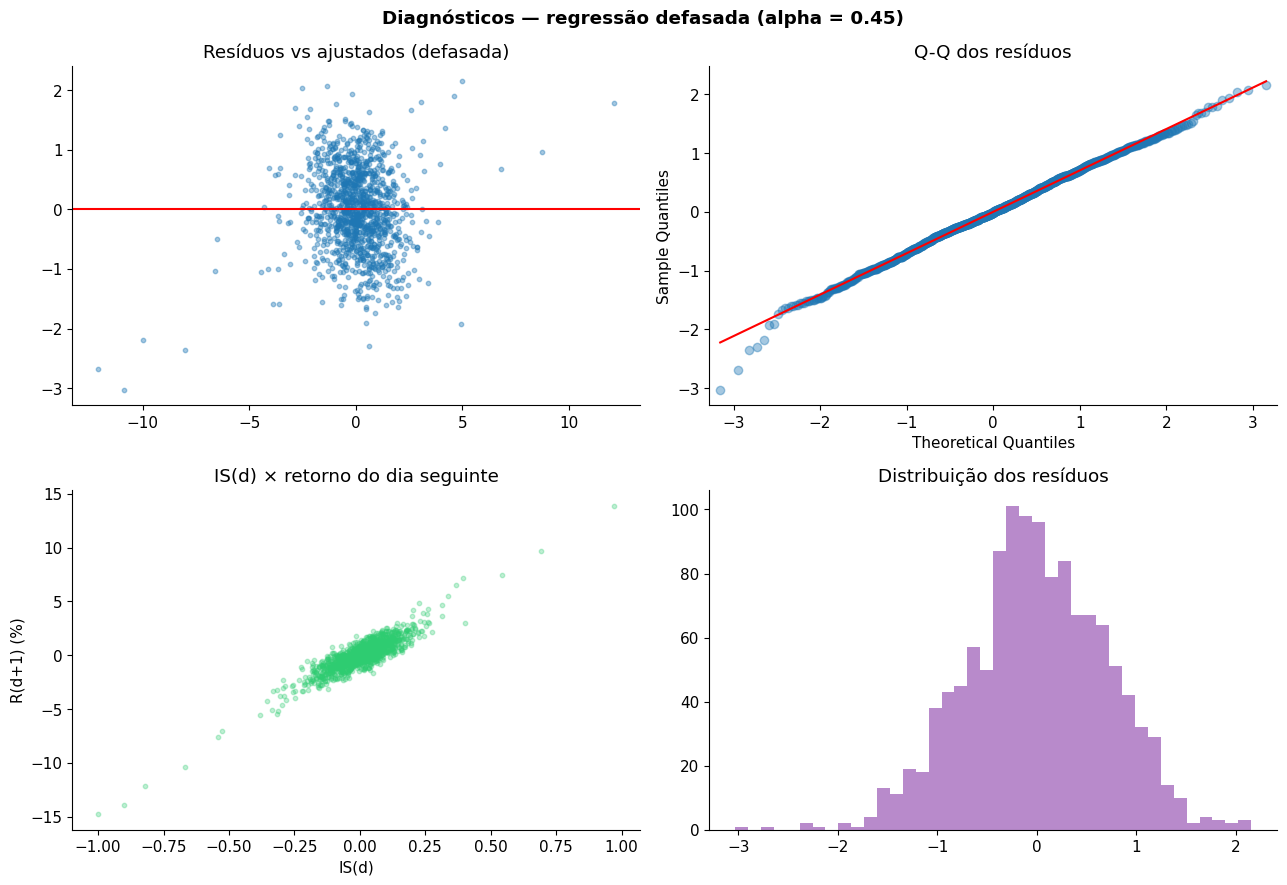

In [ ]:
m0, m1 = R['m0'], R['m1']
def resumo_reg(m, titulo):
    print('=' * 60); print(f' {titulo}'); print('=' * 60)
    print(f'  R² ajustado: {m.rsquared_adj:.4f} | F = {m.fvalue:.3f} (p = {m.f_pvalue:.4f}) | n = {int(m.nobs)} | DW = {durbin_watson(m.resid):.3f}')
    print('  {:<14}{:>10}{:>10}{:>9}{:>5}'.format('Variável','Coef','EP(HC3)','p','Sig'))
    for v in m.params.index:
        p = m.pvalues[v]; s = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.10 else ''
        print('  {:<14}{:>10.4f}{:>10.4f}{:>9.4f}{:>5}'.format(v, m.params[v], m.bse[v], p, s))
    jb = sm.stats.jarque_bera(m.resid)
    print(f'  Jarque-Bera p = {jb[1]:.4f} | cond. number = {np.linalg.cond(m.model.exog):.0f}')
resumo_reg(m0, 'REGRESSÃO SIMULTÂNEA — R(d) ~ IS(d) + ΔCâmbio + Selic + VIX')
print()
resumo_reg(m1, 'REGRESSÃO DEFASADA   — R(d+1) ~ IS(d) + ΔCâmbio + Selic + VIX')
with open('dados_tcc/regressao_v3.txt', 'w') as f:
    f.write(str(m0.summary())); f.write('\n\n'); f.write(str(m1.summary()))

# diagnósticos da regressão defasada (substitui fig9)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes[0,0].scatter(m1.fittedvalues, m1.resid, alpha=0.4, s=10); axes[0,0].axhline(0, color='red'); axes[0,0].set_title('Resíduos vs ajustados (defasada)')
sm.qqplot(m1.resid, line='s', ax=axes[0,1], alpha=0.4); axes[0,1].set_title('Q-Q dos resíduos')
axes[1,0].scatter(df_mercado['IS'].values[:-1], retornos.values[1:], alpha=0.3, s=10, color='#2ecc71')
axes[1,0].set_xlabel('IS(d)'); axes[1,0].set_ylabel('R(d+1) (%)'); axes[1,0].set_title('IS(d) × retorno do dia seguinte')
axes[1,1].hist(m1.resid, bins=40, color='#9b59b6', alpha=0.7); axes[1,1].set_title('Distribuição dos resíduos')
plt.suptitle(f'Diagnósticos — regressão defasada (alpha = {ALPHA_PRINCIPAL})', fontweight='bold'); plt.tight_layout()
plt.savefig('dados_tcc/fig9_diagnosticos_regressao.png', dpi=150, bbox_inches='tight'); plt.show()


 ANÁLISE DE EVENTOS — janela ±5 dias úteis (alpha = 0.45)
      Data        Tipo                         Evento  IS_pré  IS_pós     ΔIS  Ret_pré (%)  Ret_pós (%)  Concorda
2020-03-23       Crise                Mínima COVID-19 -0.1582  0.0782  0.2365      -3.8248       3.3998      True
2020-06-17       Copom Selic 2,25% (mínima histórica) -0.0331  0.0119  0.0450      -0.8497      -0.2409     False
2021-03-17       Copom        Início do ciclo de alta  0.0371 -0.0092 -0.0463       0.4840      -0.7767      True
2022-02-24       Crise             Invasão da Ucrânia -0.0404 -0.0552 -0.0148      -0.5536       0.0121     False
2022-08-03       Copom                Selic em 13,75%  0.0081 -0.0059 -0.0140       0.7134       1.2178     False
2022-10-30    Político        Resultado eleições 2022 -0.0000 -0.0446 -0.0446      -0.9019       0.1489     False
2023-01-12 Corporativo               Crise Americanas -0.0012  0.0517  0.0528       1.1937       0.2091      True
2023-08-02       Copom        

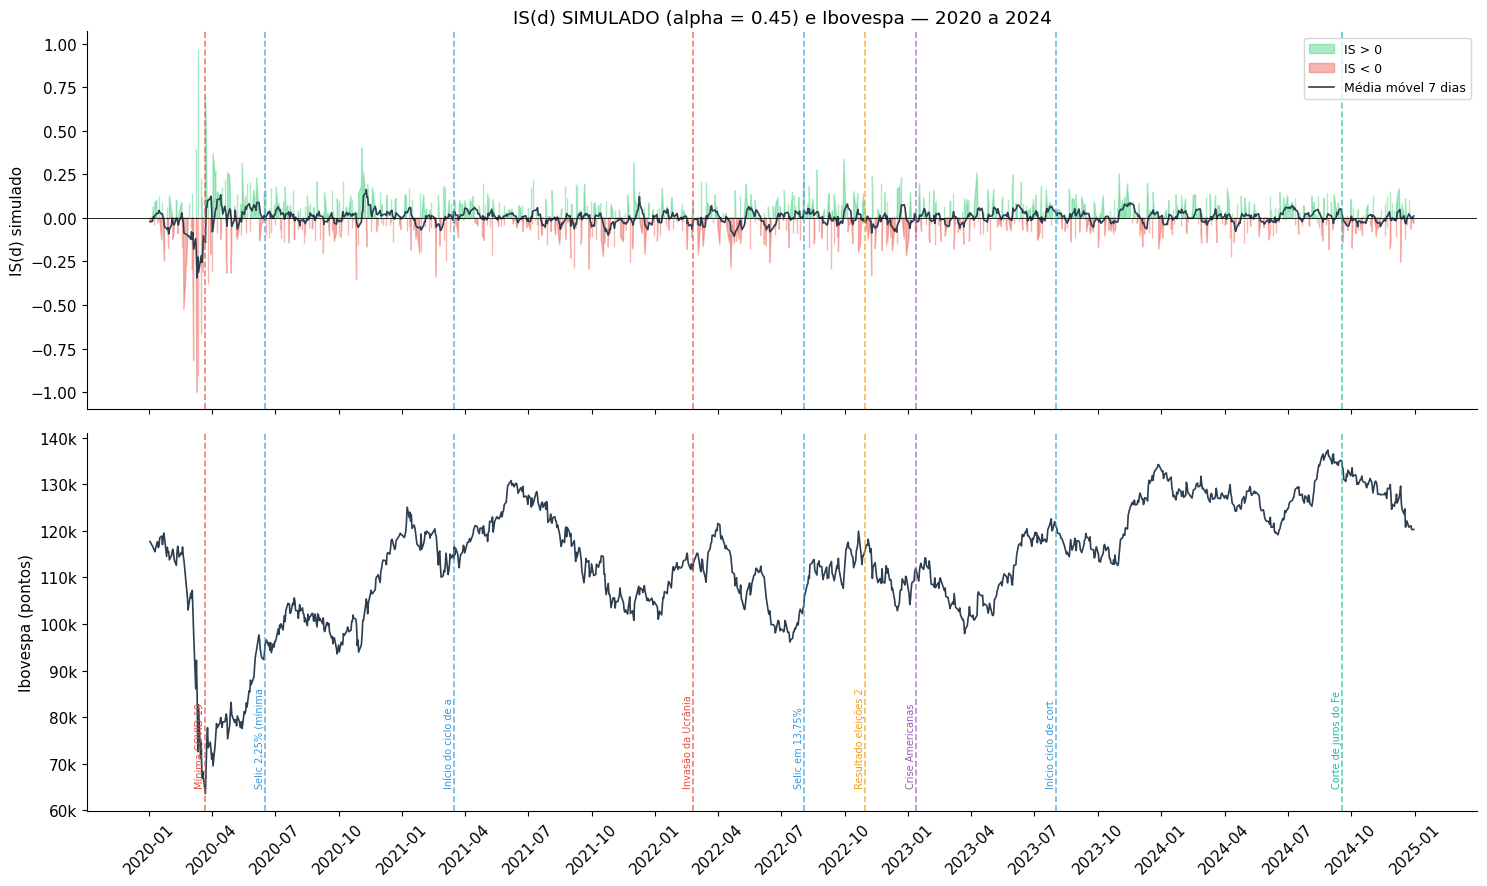

In [ ]:
ev = R['ev']
print('=' * 100); print(f' ANÁLISE DE EVENTOS — janela ±5 dias úteis (alpha = {ALPHA_PRINCIPAL})'); print('=' * 100)
print(ev.round(4).to_string(index=False))
print(f"\nEventos em que ΔIS e retorno pós-evento têm o mesmo sinal: {int(ev['Concorda'].sum())}/{len(ev)}")
ev.to_csv('dados_tcc/analise_eventos_v3.csv', index=False)

# fig10 — IS simulado e Ibovespa com eventos
fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
axes[0].fill_between(df_mercado.index, df_mercado['IS'], where=df_mercado['IS']>0, alpha=0.4, color='#2ecc71', label='IS > 0')
axes[0].fill_between(df_mercado.index, df_mercado['IS'], where=df_mercado['IS']<0, alpha=0.4, color='#e74c3c', label='IS < 0')
axes[0].plot(df_mercado.index, df_mercado['IS_ma7'], color='#2c3e50', lw=1.2, label='Média móvel 7 dias')
axes[0].axhline(0, color='black', lw=0.6); axes[0].set_ylabel('IS(d) simulado'); axes[0].legend(loc='upper right', fontsize=9)
axes[0].set_title(f'IS(d) SIMULADO (alpha = {ALPHA_PRINCIPAL}) e Ibovespa — 2020 a 2024')
axes[1].plot(df_mercado.index, df_mercado['ibovespa_fechamento'], color='#2c3e50', lw=1.2); axes[1].set_ylabel('Ibovespa (pontos)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
cores = {'Crise':'#e74c3c','Copom':'#3498db','Político':'#f39c12','Corporativo':'#9b59b6','Global':'#1abc9c'}
for e in EVENTOS:
    t = pd.Timestamp(e['data'])
    for ax in axes: ax.axvline(t, color=cores.get(e['tipo'],'gray'), lw=1.2, ls='--', alpha=0.7)
    axes[1].text(t, df_mercado['ibovespa_fechamento'].min()*1.02, e['desc'][:20], fontsize=7, rotation=90, color=cores.get(e['tipo'],'gray'), va='bottom', ha='right')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m')); axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3)); plt.xticks(rotation=45)
plt.tight_layout(); plt.savefig('dados_tcc/fig10_IS_ibovespa_eventos.png', dpi=150, bbox_inches='tight'); plt.show()


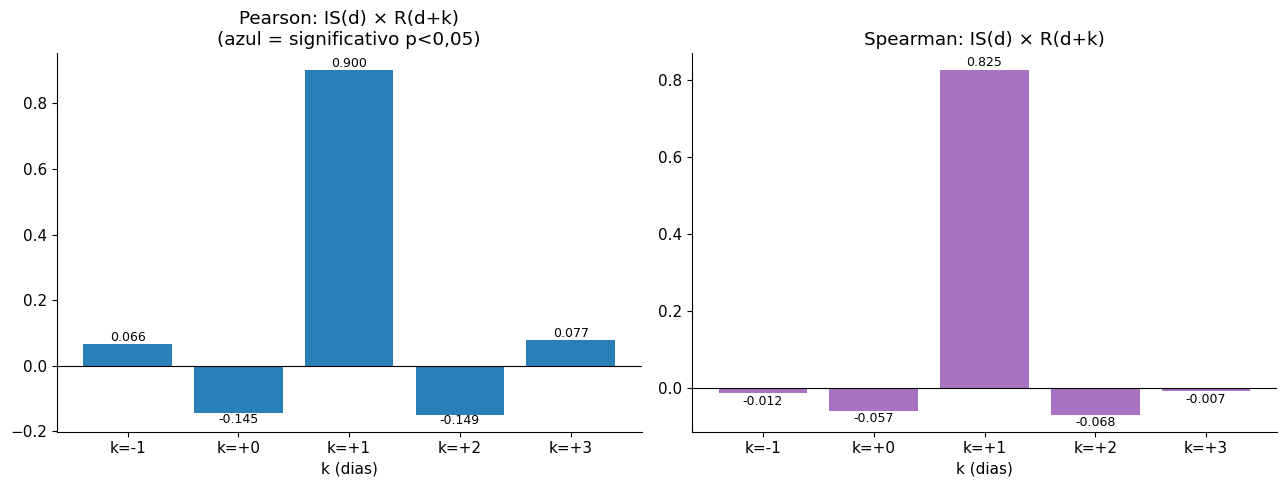

IS(d) × Google Trends (Ibovespa): r = -0.0787 (p = 0.0055) → magnitude negligenciável


In [ ]:
# fig8 — correlações por lag (convenção corrigida)
corr = R['corr']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
labs = [f'k={k:+d}' for k in corr['Lag']]
axes[0].bar(labs, corr['Pearson r'], color=['#2980b9' if p<0.05 else '#bdc3c7' for p in corr['p (Pearson)']]); axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_title('Pearson: IS(d) × R(d+k)\n(azul = significativo p<0,05)'); axes[0].set_xlabel('k (dias)')
for i, v in enumerate(corr['Pearson r']): axes[0].text(i, v + (0.01 if v>=0 else -0.03), f'{v:.3f}', ha='center', fontsize=9)
axes[1].bar(labs, corr['Spearman ρ'], color='#8e44ad', alpha=0.75); axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('Spearman: IS(d) × R(d+k)'); axes[1].set_xlabel('k (dias)')
for i, v in enumerate(corr['Spearman ρ']): axes[1].text(i, v + (0.01 if v>=0 else -0.03), f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout(); plt.savefig('dados_tcc/fig8_correlacoes_lag.png', dpi=150, bbox_inches='tight'); plt.show()

# Correlação IS × Google Trends (mantida da v2, agora com sinal explícito)
rt, pt = pearsonr(df_mercado['IS'], df_mercado['trends_ibovespa'])
print(f'IS(d) × Google Trends (Ibovespa): r = {rt:+.4f} (p = {pt:.4f}) → magnitude {"negligenciável" if abs(rt) < 0.1 else "fraca"}')


## 🤖 BLOCO 7 — Fase 4 no cenário principal: tabela SEM × COM sentimento

 TABELA — Performance preditiva SEM × COM sentimento (alpha = 0.45, CV k=5)
Cenário              Sem sentimento  Com sentimento     ΔF1  Ganho (%)  Acc sem  Acc com
Modelo                                                                                  
Gradient Boosting            0.5045          0.8157  0.3112    61.6849   0.4669   0.8111
Random Forest                0.5153          0.8239  0.3086    59.8880   0.4718   0.8168
Regressão Logística          0.5450          0.8197  0.2747    50.4007   0.4972   0.8176
MÉDIA                        0.5216          0.8197  0.2982    57.3245   0.4786   0.8152

Features: 9 (sem) vs 13 (com) | Observações: 1,223


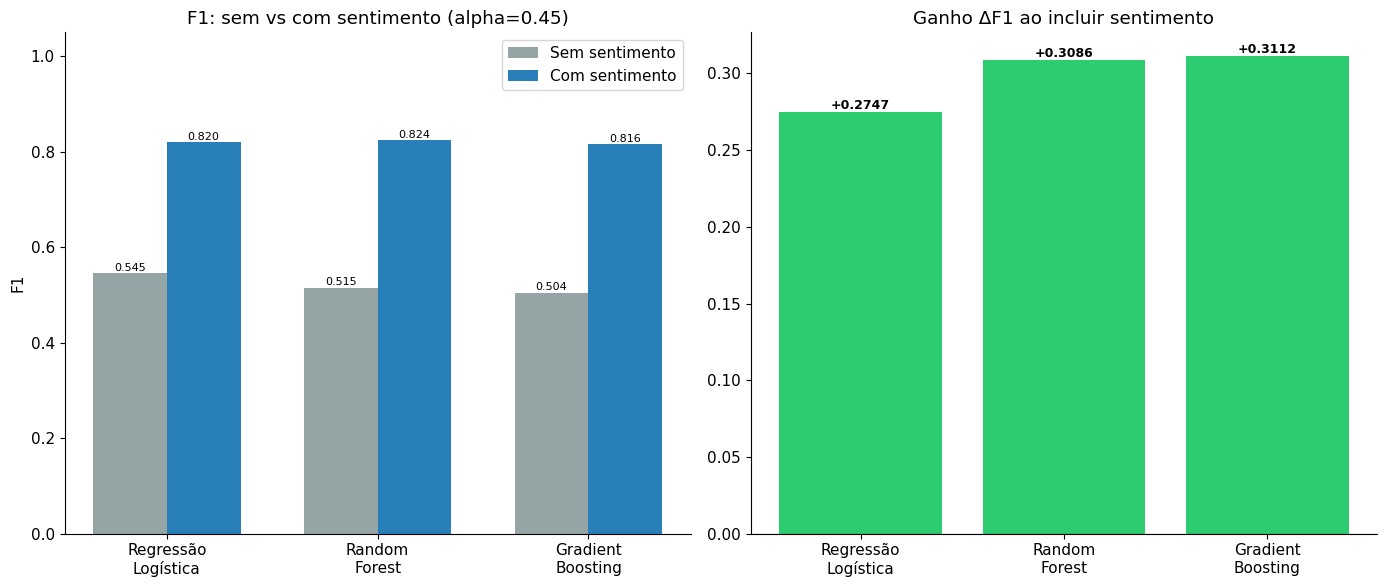

In [ ]:
comp = R['comp']
tab = comp.pivot(index='Modelo', columns='Cenário', values='F1')[['Sem sentimento','Com sentimento']]
tab['ΔF1'] = tab['Com sentimento'] - tab['Sem sentimento']; tab['Ganho (%)'] = tab['ΔF1'] / tab['Sem sentimento'] * 100
acc = comp.pivot(index='Modelo', columns='Cenário', values='Acurácia')[['Sem sentimento','Com sentimento']]
tab['Acc sem'] = acc['Sem sentimento']; tab['Acc com'] = acc['Com sentimento']
tab.loc['MÉDIA'] = tab.mean()
print('=' * 95); print(f' TABELA — Performance preditiva SEM × COM sentimento (alpha = {ALPHA_PRINCIPAL}, CV k=5)'); print('=' * 95)
print(tab.round(4).to_string())
print(f"\nFeatures: {len(FEATURES_BASE)} (sem) vs {len(FEATURES_BASE)+len(FEATURES_SENT)} (com) | Observações: {len(R['feat']):,}")
comp.to_csv('dados_tcc/resultados_comparacao_modelos_v3.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
x = np.arange(len(MODELOS)); w = 0.35; mods = list(MODELOS.keys())
f1s = tab.loc[mods, 'Sem sentimento']; f1c = tab.loc[mods, 'Com sentimento']
axes[0].bar(x-w/2, f1s, w, label='Sem sentimento', color='#95a5a6'); axes[0].bar(x+w/2, f1c, w, label='Com sentimento', color='#2980b9')
for i,(a,b) in enumerate(zip(f1s,f1c)): axes[0].text(i-w/2, a+0.005, f'{a:.3f}', ha='center', fontsize=8); axes[0].text(i+w/2, b+0.005, f'{b:.3f}', ha='center', fontsize=8)
axes[0].set_xticks(x); axes[0].set_xticklabels([m.replace(' ','\n') for m in mods]); axes[0].set_ylim(0,1.05); axes[0].set_ylabel('F1'); axes[0].legend(); axes[0].set_title(f'F1: sem vs com sentimento (alpha={ALPHA_PRINCIPAL})')
g = tab.loc[mods, 'ΔF1']; axes[1].bar(mods, g, color=['#2ecc71' if v>0 else '#e74c3c' for v in g]); axes[1].axhline(0, color='black', lw=0.8)
for i,v in enumerate(g): axes[1].text(i, v+0.002, f'{v:+.4f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_xticklabels([m.replace(' ','\n') for m in mods]); axes[1].set_title('Ganho ΔF1 ao incluir sentimento')
plt.tight_layout(); plt.savefig('dados_tcc/fig12_comparacao_sem_com_sentimento.png', dpi=150, bbox_inches='tight'); plt.show()


## 👤 BLOCO 8 — Camada 3: recomendações por perfil de suitability

Idêntico à v2. Betas e retornos de 12 meses do universo de ativos são **valores ilustrativos fixados manualmente** (não coletados) — isso está declarado no TCC. A lógica: score = retorno_12m / beta, ajustado pelo IS(d) atual, filtrado pelo beta máximo do perfil, top-5, alocação proporcional dentro do limite de renda variável do perfil.

IS(d) atual (último pregão): -0.0315

 PERFIL CONSERVADOR — RV máx 10%
ticker      setor  beta  retorno_12m  alocacao_pct  sinal
 WEGE3 Industrial  0.75         28.4          10.0 Neutro

 PERFIL MODERADO — RV máx 30%
ticker      setor  beta  retorno_12m  alocacao_pct  sinal
 WEGE3 Industrial  0.75         28.4          14.0 Neutro
 ITUB4 Financeiro  0.90         22.1           9.1 Neutro
 BBDC4 Financeiro  0.85         15.7           6.9 Neutro

 PERFIL ARROJADO — RV máx 70%
ticker      setor  beta  retorno_12m  alocacao_pct  sinal
 WEGE3 Industrial  0.75         28.4          24.7 Neutro
 ITUB4 Financeiro  0.90         22.1          16.0 Neutro
 BBDC4 Financeiro  0.85         15.7          12.0 Neutro
 PETR4    Energia  1.20         18.5          10.0 Neutro
 VALE3  Mineracao  1.10         12.3           7.3 Neutro

 DEMONSTRAÇÃO — perfil Arrojado sob IS = -0,6 / 0,0 / +0,6 (ativos com beta > 1 são penalizados quando IS < limiar)
IS = -0.6 | sinal = Cautela | alocação: WEGE3 27.2%, I

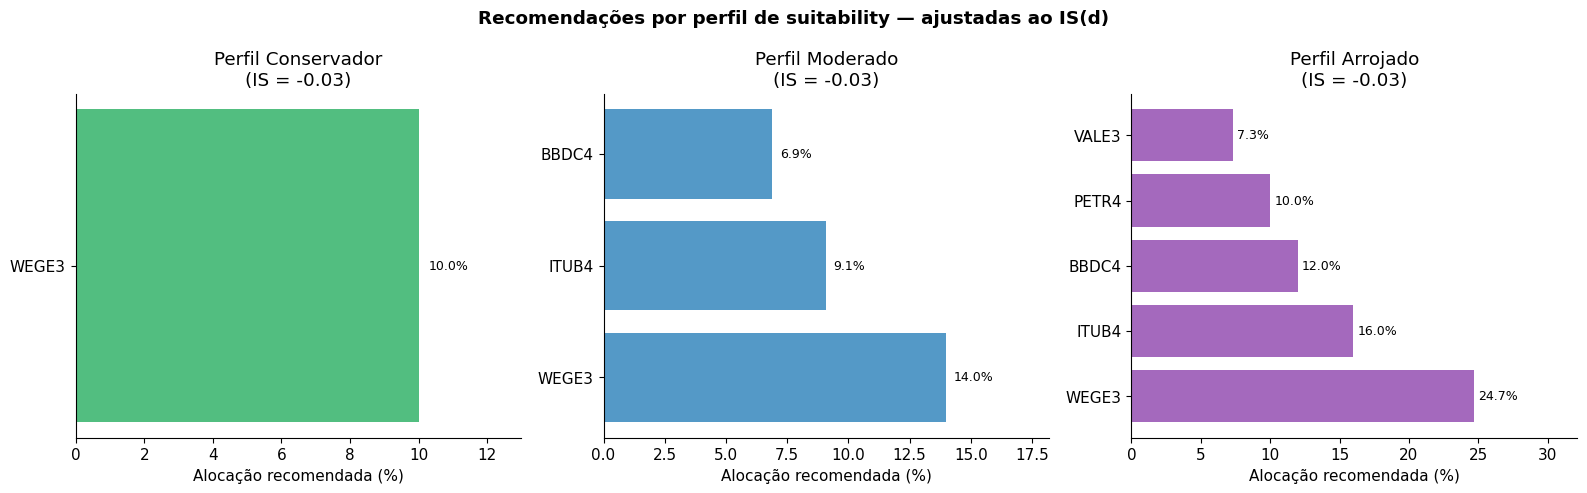

In [ ]:
PERFIS_SUITABILITY = {
    'Conservador': {'risco_max': 0.30, 'alocacao_renda_var': 0.10, 'IS_threshold': 0.3},
    'Moderado':    {'risco_max': 0.50, 'alocacao_renda_var': 0.30, 'IS_threshold': 0.1},
    'Arrojado':    {'risco_max': 1.00, 'alocacao_renda_var': 0.70, 'IS_threshold': -0.1},
}
ATIVOS_UNIVERSO = [  # valores ILUSTRATIVOS
    {'ticker':'PETR4','setor':'Energia',   'beta':1.20,'retorno_12m':18.5},
    {'ticker':'VALE3','setor':'Mineracao', 'beta':1.10,'retorno_12m':12.3},
    {'ticker':'ITUB4','setor':'Financeiro','beta':0.90,'retorno_12m':22.1},
    {'ticker':'BBDC4','setor':'Financeiro','beta':0.85,'retorno_12m':15.7},
    {'ticker':'WEGE3','setor':'Industrial','beta':0.75,'retorno_12m':28.4},
    {'ticker':'RENT3','setor':'Servicos',  'beta':1.30,'retorno_12m':8.2},
    {'ticker':'MGLU3','setor':'Varejo',    'beta':1.80,'retorno_12m':-22.1},
    {'ticker':'LREN3','setor':'Varejo',    'beta':1.40,'retorno_12m':5.6},
]
df_ativos = pd.DataFrame(ATIVOS_UNIVERSO)

def gerar_recomendacao(perfil_nome, IS_atual, df_ativos_input):
    p = PERFIS_SUITABILITY[perfil_nome]; d = df_ativos_input.copy()
    d['score_base'] = d['retorno_12m'] / d['beta']
    if IS_atual < p['IS_threshold']:
        d['ajuste_IS'] = np.where(d['beta'] > 1.0, d['score_base']*(1 + IS_atual*0.5), d['score_base']*(1 - IS_atual*0.2))
    else:
        d['ajuste_IS'] = d['score_base'] * (1 + IS_atual*0.3)
    d = d[d['beta'] <= p['risco_max'] + 0.5].sort_values('ajuste_IS', ascending=False).head(5)
    total = d['ajuste_IS'].clip(lower=0).sum()
    d['alocacao_pct'] = (d['ajuste_IS'].clip(lower=0)/total*p['alocacao_renda_var']*100).round(1) if total > 0 else 0
    d['sinal'] = np.where(IS_atual > 0.1, 'Compra', np.where(IS_atual < -0.1, 'Cautela', 'Neutro'))
    return d[['ticker','setor','beta','retorno_12m','alocacao_pct','sinal']]

IS_ATUAL = df_mercado['IS'].iloc[-1]
print(f'IS(d) atual (último pregão): {IS_ATUAL:+.4f}\n')
for perfil in PERFIS_SUITABILITY:
    print('=' * 60); print(f' PERFIL {perfil.upper()} — RV máx {PERFIS_SUITABILITY[perfil]["alocacao_renda_var"]*100:.0f}%'); print('=' * 60)
    print(gerar_recomendacao(perfil, IS_ATUAL, df_ativos).to_string(index=False)); print()

# Demonstração do ajuste dinâmico: mesma carteira sob três estados de sentimento
print('=' * 60); print(' DEMONSTRAÇÃO — perfil Arrojado sob IS = -0,6 / 0,0 / +0,6 (ativos com beta > 1 são penalizados quando IS < limiar)'); print('=' * 60)
for is_demo in [-0.6, 0.0, 0.6]:
    r = gerar_recomendacao('Arrojado', is_demo, df_ativos)
    print(f'IS = {is_demo:+.1f} | sinal = {r["sinal"].iloc[0]} | alocação: ' + ', '.join(f'{t} {a:.1f}%' for t, a in zip(r['ticker'], r['alocacao_pct'])))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (perfil, cor) in zip(axes, zip(PERFIS_SUITABILITY, ['#27ae60','#2980b9','#8e44ad'])):
    r = gerar_recomendacao(perfil, IS_ATUAL, df_ativos); r = r[r['alocacao_pct']>0]
    ax.barh(r['ticker'], r['alocacao_pct'], color=cor, alpha=0.8)
    for i, v in enumerate(r['alocacao_pct']): ax.text(v+0.3, i, f'{v:.1f}%', va='center', fontsize=9)
    ax.set_title(f'Perfil {perfil}\n(IS = {IS_ATUAL:+.2f})'); ax.set_xlabel('Alocação recomendada (%)'); ax.set_xlim(0, r['alocacao_pct'].max()*1.3)
plt.suptitle('Recomendações por perfil de suitability — ajustadas ao IS(d)', fontweight='bold'); plt.tight_layout()
plt.savefig('dados_tcc/fig13_recomendacoes_por_perfil.png', dpi=150, bbox_inches='tight'); plt.show()


## 📋 BLOCO 9 — Números para colar no TCC

Imprime, agrupados por tabela do documento, todos os valores que estão marcados em amarelo na versão v2 do texto.

In [ ]:
print('#' * 70); print(' NÚMEROS PARA O TCC (versão v2 do texto — campos em amarelo)'); print('#' * 70)
c = R['corr'].set_index('Lag')
print('\n[TABELA 5 — correlações, alpha=0,45]')
for k in c.index: print(f"  k={k:+d}: Pearson {c.loc[k,'Pearson r']:+.4f} (p={c.loc[k,'p (Pearson)']:.4f}) | Spearman {c.loc[k,'Spearman ρ']:+.4f}")
print(f"  IS real (n=15): Pearson {rr:+.4f} (p={pr:.3f}) | Spearman {rs_:+.4f} (p={ps_:.3f})")
print('\n[TABELA 6 — regressão DEFASADA R(d+1) ~ IS(d) + controles]')
print(f"  R² aj = {m1.rsquared_adj:.4f} | F = {m1.fvalue:.3f} (p = {m1.f_pvalue:.4f}) | n = {int(m1.nobs)} | DW = {durbin_watson(m1.resid):.3f}")
for v in m1.params.index: print(f"  {v:<14} coef {m1.params[v]:+.4f} | EP {m1.bse[v]:.4f} | p {m1.pvalues[v]:.4f}")
print('\n[TABELA 6b — regressão SIMULTÂNEA R(d) ~ IS(d) + controles]')
print(f"  R² aj = {m0.rsquared_adj:.4f} | F = {m0.fvalue:.3f} (p = {m0.f_pvalue:.4f})")
for v in m0.params.index: print(f"  {v:<14} coef {m0.params[v]:+.4f} | EP {m0.bse[v]:.4f} | p {m0.pvalues[v]:.4f}")
print('\n[TABELA 7 — eventos]'); print(ev[['Data','Evento','ΔIS','Ret_pós (%)','Concorda']].round(4).to_string(index=False))
print('\n[TABELA 8 — F1 sem × com, alpha=0,45]'); print(tab.round(4).to_string())
print('\n[TABELA 9 — sensibilidade]'); print(df_sens.round(4).to_string(index=False))
print(f'\n[4.1.3] IS × Trends: r = {rt:+.4f} (p = {pt:.4f})')
print('\nArquivos gerados em TCC_dados/: correlacoes_IS_ibovespa_v3.csv, regressao_v3.txt, analise_eventos_v3.csv,')
print('  resultados_comparacao_modelos_v3.csv, sensibilidade_alpha_v3.csv, fig8/fig9/fig10/fig12/fig13 (atualizadas), fig14 (nova)')


######################################################################
 NÚMEROS PARA O TCC (versão v2 do texto — campos em amarelo)
######################################################################

[TABELA 5 — correlações, alpha=0,45]
  k=-1: Pearson +0.0659 (p=0.0203) | Spearman -0.0124
  k=+0: Pearson -0.1453 (p=0.0000) | Spearman -0.0573
  k=+1: Pearson +0.9005 (p=0.0000) | Spearman +0.8253
  k=+2: Pearson -0.1486 (p=0.0000) | Spearman -0.0675
  k=+3: Pearson +0.0771 (p=0.0066) | Spearman -0.0069
  IS real (n=15): Pearson -0.0963 (p=0.754) | Spearman +0.1464 (p=0.633)

[TABELA 6 — regressão DEFASADA R(d+1) ~ IS(d) + controles]
  R² aj = 0.8111 | F = 357.228 (p = 0.0000) | n = 1241 | DW = 2.141
  const          coef -0.1065 | EP 0.1060 | p 0.3149
  IS             coef +12.2849 | EP 0.3460 | p 0.0000
  delta_cambio   coef -0.0223 | EP 0.0210 | p 0.2877
  selic_proxy    coef -0.2817 | EP 1.2538 | p 0.8222
  vix            coef +0.0049 | EP 0.0042 | p 0.2403

[TABELA 6b — regressã